# 02 — Training Monitoring

Visualise training dynamics from saved checkpoint metadata:
- Loss curves (train / val)
- AUROC / F1 per epoch
- Early stopping behaviour
- Effect of learning rate reduction

The `ClassifierModel.fit()` method saves a `history.json` alongside each `best.pt` checkpoint.
Point this notebook at that directory to explore the run.

In [1]:
import json
import sys
from pathlib import Path

ROOT = Path("..")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

## Configuration

In [9]:
# Set this to a checkpoint directory produced by the training scripts.
# Example: ROOT / "output/ulcer/models/detection/vits16_imagenet/run_20260604_120000"
CHECKPOINT_DIR = ROOT / "output/ulcer/models"

# Or point directly at a history.json file:
HISTORY_JSON = None  # e.g. Path("output/.../history.json")

## 1. Load Training History

In [10]:
def find_history_files(root: Path) -> list[Path]:
    """Recursively find all history.json files under root."""
    return sorted(root.glob("**/history.json")) if root.exists() else []


def load_history(json_path: Path) -> pd.DataFrame:
    with open(json_path) as f:
        data = json.load(f)
    return pd.DataFrame(data)


if HISTORY_JSON:
    histories = {HISTORY_JSON.parent.name: load_history(HISTORY_JSON)}
else:
    found = find_history_files(CHECKPOINT_DIR)
    print(f"Found {len(found)} history file(s) under {CHECKPOINT_DIR}")
    histories = {}
    for p in found:
        run_name = "/".join(p.parts[-3:-1])  # e.g. "model_name/timestamp"
        try:
            histories[run_name] = load_history(p)
        except Exception as e:
            print(f"  Could not load {p}: {e}")

if not histories:
    print(
        "\n  No training history found yet.\n"
        "  Run at least one training job first:\n"
        "\n"
        "    python -m scripts.ulcer.run_data_efficiency --subset-ratios 0.1 --seeds 42 --epochs 5\n"
        "    python -m scripts.mes.run_data_efficiency   --subset-ratios 0.1 --seeds 42 --epochs 5\n"
        "\n"
        "  Then update CHECKPOINT_DIR above to point at the output directory."
    )
else:
    print(f"Loaded {len(histories)} run(s)")
    sample = next(iter(histories.values()))
    print(f"Columns: {list(sample.columns)}")
    display(sample.head(3))

Found 2 history file(s) under ..\output\ulcer\models
Loaded 2 run(s)
Columns: ['epoch', 'train_loss', 'train_acc', 'val_loss', 'val_acc', 'val_f1', 'val_auroc', 'lr', 'is_best']


,epoch,train_loss,train_acc,val_loss,val_acc,val_f1,val_auroc,lr,is_best
0,1,0.843012,0.496552,0.869782,0.584615,0.624526,0.614598,0.000030,True
1,2,0.786735,0.600000,0.869798,0.546853,0.539773,0.600628,0.000027,False
2,3,0.745426,0.679310,0.883208,0.485315,0.452381,0.533105,0.000020,False


## 2. Loss Curves

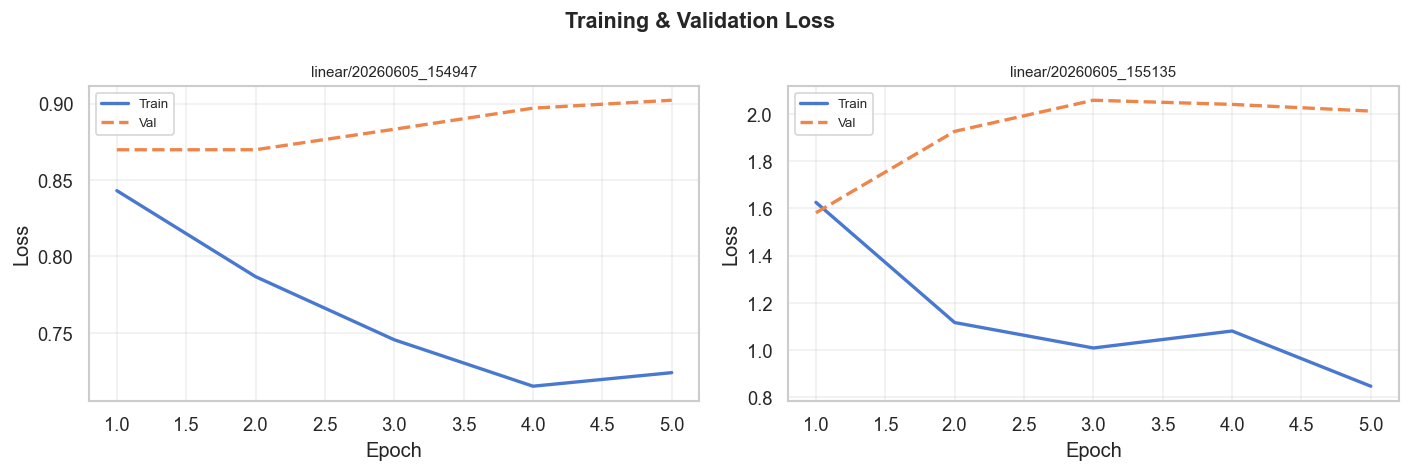

In [11]:
def plot_loss_curves(histories: dict[str, pd.DataFrame], max_plots: int = 6) -> None:
    items = list(histories.items())[:max_plots]
    n = len(items)
    if n == 0:
        print("No histories to plot.")
        return

    ncols = min(n, 3)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), squeeze=False)
    fig.suptitle("Training & Validation Loss", fontsize=13, fontweight="bold")

    for idx, (name, df) in enumerate(items):
        ax = axes[idx // ncols][idx % ncols]
        if "train_loss" in df.columns:
            ax.plot(df["epoch"] if "epoch" in df else range(len(df)), df["train_loss"],
                    label="Train", linewidth=2)
        if "val_loss" in df.columns:
            ax.plot(df["epoch"] if "epoch" in df else range(len(df)), df["val_loss"],
                    label="Val", linewidth=2, linestyle="--")
        ax.set_title(name, fontsize=9)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    # Hide empty subplots
    for idx in range(n, nrows * ncols):
        axes[idx // ncols][idx % ncols].set_visible(False)

    fig.tight_layout()
    plt.show()

plot_loss_curves(histories)

## 3. AUROC and F1 per Epoch

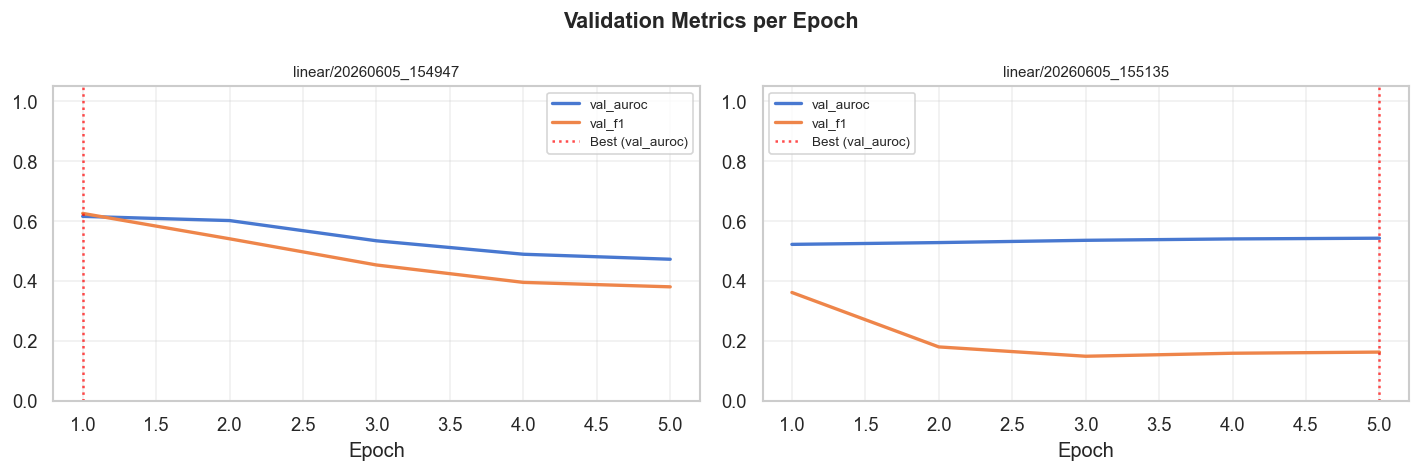

In [12]:
def plot_metric_curves(
    histories: dict[str, pd.DataFrame],
    metrics: list[str] = ("val_auroc", "val_f1"),
    max_plots: int = 6,
) -> None:
    items = list(histories.items())[:max_plots]
    n = len(items)
    if n == 0:
        return

    ncols = min(n, 3)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), squeeze=False)
    fig.suptitle("Validation Metrics per Epoch", fontsize=13, fontweight="bold")

    for idx, (name, df) in enumerate(items):
        ax = axes[idx // ncols][idx % ncols]
        x = df["epoch"] if "epoch" in df else range(len(df))
        for metric in metrics:
            if metric in df.columns:
                ax.plot(x, df[metric], label=metric, linewidth=2)
        # Mark the best epoch
        best_col = "val_auroc" if "val_auroc" in df.columns else metrics[0] if metrics[0] in df.columns else None
        if best_col:
            best_idx = df[best_col].idxmax()
            ax.axvline(x=df.loc[best_idx, "epoch"] if "epoch" in df.columns else best_idx,
                       color="red", linestyle=":", alpha=0.7, label=f"Best ({best_col})")
        ax.set_title(name, fontsize=9)
        ax.set_xlabel("Epoch")
        ax.set_ylim(0, 1.05)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    for idx in range(n, nrows * ncols):
        axes[idx // ncols][idx % ncols].set_visible(False)

    fig.tight_layout()
    plt.show()

plot_metric_curves(histories)

## 4. Compare Runs Side-by-Side

In [13]:
def compare_best_metrics(histories: dict[str, pd.DataFrame]) -> pd.DataFrame:
    """Extract the best epoch metrics from each run."""
    rows = []
    for name, df in histories.items():
        best_col = next((c for c in ("val_auroc", "val_f1") if c in df.columns), None)
        if best_col is None:
            continue
        best_row = df.loc[df[best_col].idxmax()].to_dict()
        best_row["run"] = name
        rows.append(best_row)
    return pd.DataFrame(rows).set_index("run") if rows else pd.DataFrame()

best_df = compare_best_metrics(histories)
if not best_df.empty:
    metric_cols = [c for c in best_df.columns if any(m in c for m in ("auroc", "f1", "loss"))]
    display(best_df[metric_cols].round(4).sort_values(
        [c for c in ("val_auroc", "val_f1") if c in metric_cols][:1], ascending=False
    ))

,train_loss,val_loss,val_f1,val_auroc
run,,,,
linear/20260605_154947,0.8430,0.8698,0.6245,0.6146
linear/20260605_155135,0.8474,2.0117,0.1616,0.5417


## 5. Early Stopping Analysis

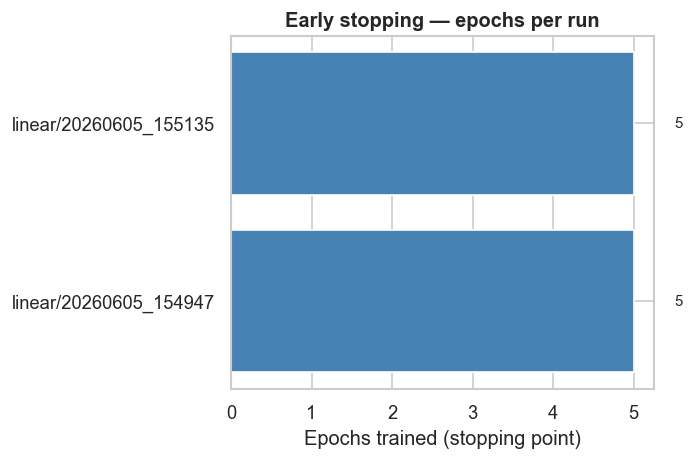

In [14]:
def plot_stopping_epochs(histories: dict[str, pd.DataFrame]) -> None:
    if not histories:
        return

    names = list(histories.keys())
    n_epochs = [len(df) for df in histories.values()]

    fig, ax = plt.subplots(figsize=(max(6, len(names) * 0.8), 4))
    bars = ax.barh(names, n_epochs, color="steelblue")
    for bar, n in zip(bars, n_epochs):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                str(n), va="center", fontsize=9)
    ax.set_xlabel("Epochs trained (stopping point)")
    ax.set_title("Early stopping — epochs per run", fontweight="bold")
    fig.tight_layout()
    plt.show()

plot_stopping_epochs(histories)